Tutorial 4: Designing a Custom Target — the Smiley Face
=============================================================================

In Tutorial 1 we used a biologically motivated target: a strong insulated
boundary. The boundary mask was rectangular, well-understood, and grounded
in real Hi-C data.

But what is a "target" really? It is just a vector of desired values for
some entries of the predicted contact map. There is nothing stopping you
from defining *any* pattern you like — as long as you can express it as a
mask over the upper-triangular contact map.

This tutorial uses a smiley face 🙂 as the target pattern. 
Eyes and a curved mouth are stamped onto the 512×512 contact map,
and Ledidi is asked to find a sequence whose Akita prediction matches that
pattern.

Why a smiley face?
------------------
Smiley faces do not occur in Hi-C data. Akita has never seen one, and there
is no biological reason to expect the sequence optimiser to produce one.
This makes the exercise a perfect stress test: if the design *does* look
smiley-like, the optimiser is remarkably powerful; if it does not, that is
also informative. Either way, the tutorial illustrates the key message:

    The only hard requirement for a custom target is that you can write a
    function that converts your idea into an upper-triangular mask vector.
    Everything else — the loss function, the optimiser, the evaluation — is
    identical to any other AkitaSF design run.

─────────────────────────────────────────────────────────────────────────────
A note on interpreting results
─────────────────────────────────────────────────────────────────────────────
Because smiley faces are out-of-distribution for Akita, the optimised
contact map should be assessed *visually* and taken critically:
- Partial smiley-like features are interesting but not reliable designs.
- Any result that looks suspicious should be discarded or inspected further.     

This is true for all AkitaSF designs, not just whimsical ones: always
visualise your contact maps before drawing biological conclusions.

─────────────────────────────────────────────────────────────────────────────
Prerequisites
─────────────────────────────────────────────────────────────────────────────
Same environment as Tutorial 1. See environment.yml / requirements.txt.    
All cluster-specific paths are in the CONFIGURATION cell below.

## Cell 1 — Imports

In [1]:
import os
import sys
import shutil

import numpy as np
import torch
import matplotlib.pyplot as plt
from pyfaidx import Fasta

# AKITA_PT_PATH  = "/path/to/akita_pytorch"
# LEDIDI_PATH    = "/path/to/ledidi/ledidi"
# AKITA_SF_PATH  = "/path/to/akita_semifreddo"

AKITA_PT_PATH  = "/home1/smaruj/akita_pytorch/"
LEDIDI_PATH    = "/home1/smaruj/ledidi/ledidi/"
AKITA_SF_PATH  = "/home1/smaruj/akita_semifreddo"

sys.path.append(os.path.abspath(AKITA_PT_PATH))
sys.path.insert(0, LEDIDI_PATH)
sys.path.insert(0, os.path.abspath(AKITA_SF_PATH))

from akita.model import SeqNN
from ledidi import Ledidi
from semifreddo.semifreddo import SemifreddoLedidiWrapper
from semifreddo.losses import LocalL1Loss
from utils.model_utils import store_tower_output, make_target
from utils.data_utils import (
    one_hot_encode_sequence,
    from_upper_triu,
    upper_triangular_to_vector,
    fragment_indices_in_upper_triangular,
)

print("All imports successful.")

All imports successful.


## Cell 2 — Configuration

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
# MODEL_PATH = "/path/to/Akita_v2_mouse_Hsieh2019_mESC_model0_finetuned.pth"
# FASTA_PATH = "/path/to/mm10.fa"

MODEL_PATH = ("/home1/smaruj/akita_pytorch/models/finetuned/mouse/Hsieh2019_mESC/checkpoints/"
              "Akita_v2_mouse_Hsieh2019_mESC_model0_finetuned.pth")
FASTA_PATH = "/project2/fudenber_735/genomes/mm10/mm10.fa"

PWM_PATH   = "./../data/pwm/MA0139.1.meme"

# ── Genomic locus ─────────────────────────────────────────────────────────────
# Same flat region as Tutorial 1 — a featureless starting point keeps the
# result attributable to the optimiser rather than the initial sequence.
CHROM = "chr5"
START = 97957888
END   = 99268608
STEM  = f"{CHROM}_{START}_{END}"

TMP_DIR = "tmp_data"

# ── Architectural constants ───────────────────────────────────────────────────
MAP_SIZE       = 512
NUM_DIAGS      = 2
CENTER_BIN_MAP = 256
CROPPING       = 64
BIN_SIZE       = 2048
CONTEXT_BINS   = 5
N_TRIU         = 130305

# ── Smiley face parameters ────────────────────────────────────────────────────
# These control the geometry of the smiley; feel free to experiment.
SMILEY_VALUE      = 0.5   # contact enrichment value stamped into smiley features
EYE_RADIUS        = 10
MOUTH_RADIUS      = 100
MOUTH_THICKNESS   = 8

# ── Optimisation hyperparameters ──────────────────────────────────────────────
L              = 125.0
MAX_ITER       = 2000
EARLY_STOPPING = 2000

# ── Visualisation ─────────────────────────────────────────────────────────────
VMIN, VMAX = -0.6, 0.6
CMAP       = "RdBu_r"

print("Configuration ready.")

Configuration ready.


## Cell 3 — Defining the smiley face mask

This is the heart of the tutorial. We define a function that constructs a
512×512 boolean mask (and a corresponding value matrix) whose non-zero
entries trace out a smiley face aligned with the main diagonal.

The diagonal alignment is intentional: the diagonal of a contact map
represents short-range contacts, so features placed there have the strongest
biological plausibility for Akita to "reach for" during optimisation.

Once you understand this function, you can replace it with any shape you
like — stripes, a cross, a checkerboard, your initials. The rest of the
pipeline stays exactly the same.

In [3]:
def create_smiley_along_diagonal_value_mask(
    shape=(512, 512),
    eye_radius=10,
    mouth_radius=75,
    mouth_thickness=8,
    c=0.5,
):
    """
    Create a smiley face (eyes + curved mouth) whose axis of symmetry is the
    main diagonal of the contact map.

    The smile arc spans the diagonal: half in the upper triangle, half in the
    lower. This is achieved by defining the arc in a coordinate system rotated
    45° relative to the matrix axes, then mirroring it across the diagonal.

    Parameters
    ----------
    shape : (H, W)
        Matrix shape; should match Akita's contact map size (512, 512).
    eye_radius : int
        Radius of the circular eyes in bins.
    mouth_radius : int
        Curvature radius of the smile arc in bins.
    mouth_thickness : int
        Half-thickness of the smile arc in bins.
    c : float
        Value assigned to smiley features in the value mask.

    Returns
    -------
    bool_mask  : (H, W) bool array   — True where smiley features are
    value_mask : (H, W) float32 array — 0 outside, c inside smiley features
    """
    H, W = shape
    i, j = np.meshgrid(
        np.arange(H, dtype=np.float32),
        np.arange(W, dtype=np.float32),
        indexing="ij",
    )
    center = np.array([H / 2, W / 2], dtype=np.float32)

    # ── Eyes ──────────────────────────────────────────────────────────────────
    eye_offset  = min(H, W) * 0.25
    eye1_center = center - np.array([eye_offset, 0], dtype=np.float32)
    eye2_center = eye1_center[::-1]   # mirror across the diagonal

    eye1 = ((i - eye1_center[0])**2 + (j - eye1_center[1])**2) <= eye_radius**2
    eye2 = ((i - eye2_center[0])**2 + (j - eye2_center[1])**2) <= eye_radius**2

    # ── Mouth ─────────────────────────────────────────────────────────────────
    # Shift to centre, rotate 45° so the main diagonal becomes the x-axis,
    # then define a circular arc below the new x-axis.
    x, y  = i - center[0], j - center[1]
    theta = np.deg2rad(45)
    x_rot =  x * np.cos(theta) - y * np.sin(theta)
    y_rot =  x * np.sin(theta) + y * np.cos(theta)

    smile_center_y = mouth_radius / 2
    dist  = np.sqrt(x_rot**2 + (y_rot - smile_center_y)**2)
    mouth = (dist >= mouth_radius - mouth_thickness) & \
            (dist <= mouth_radius + mouth_thickness) & \
            (y_rot > 0)
    mouth_mask = mouth | mouth.T   # mirror to enforce diagonal symmetry

    # ── Combine ───────────────────────────────────────────────────────────────
    bool_mask  = eye1 | eye2 | mouth_mask
    value_mask = np.zeros(shape, dtype=np.float32)
    value_mask[bool_mask] = c

    return bool_mask, value_mask

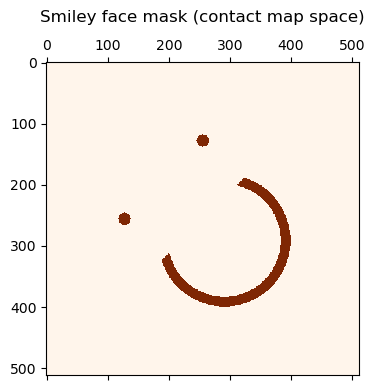

Non-zero bins in mask : 7,321 / 262,144
This is the pattern we will ask Ledidi to stamp into the contact map.


In [4]:
# Preview the smiley face pattern before running any optimisation.
bool_mask, value_mask = create_smiley_along_diagonal_value_mask(
    shape          = (MAP_SIZE, MAP_SIZE),
    eye_radius     = EYE_RADIUS,
    mouth_radius   = MOUTH_RADIUS,
    mouth_thickness= MOUTH_THICKNESS,
    c              = SMILEY_VALUE,
)

fig, ax = plt.subplots(figsize=(5, 4))
ax.matshow(value_mask, cmap="Oranges", vmin=0, vmax=SMILEY_VALUE)
ax.set_title("Smiley face mask (contact map space)", pad=12)
plt.tight_layout()
plt.show()

print(f"Non-zero bins in mask : {bool_mask.sum():,} / {MAP_SIZE * MAP_SIZE:,}")
print("This is the pattern we will ask Ledidi to stamp into the contact map.")

## Cell 4 — Converting the smiley mask to upper-triangular format

Akita's output is an upper-triangular vector (with the first NUM_DIAGS
diagonals excluded). We need to:
1. Extract the indices of the smiley entries within that vector.
2. Build the corresponding value vector (zeros everywhere, SMILEY_VALUE
at smiley positions).

These two objects are exactly analogous to the boundary mask built in
Tutorial 1 — the only difference is their shape.

In [5]:
smiley_vector  = torch.tensor(
    upper_triangular_to_vector(value_mask, NUM_DIAGS)
).float()

smiley_indices = torch.tensor(
    fragment_indices_in_upper_triangular(
        matrix_size   = MAP_SIZE,
        fragment_mask = bool_mask,
    )
)

print(f"Smiley upper-tri vector length : {smiley_vector.shape[0]:,}  (= N_TRIU = {N_TRIU:,})")
print(f"Non-zero entries in vector     : {(smiley_vector != 0).sum().item():,}")
print(f"Mask index tensor shape        : {tuple(smiley_indices.shape)}")

Smiley upper-tri vector length : 130,305  (= N_TRIU = 130,305)
Non-zero entries in vector     : 3,643
Mask index tensor shape        : (3643,)


## Cell 5 — Pre-computing sequence, tower output, and smiley target

Identical to Tutorial 1: extract the sequence, run the convolutional tower
once to cache activations, then build the target by adding the smiley mask
to the initial model prediction.

Device: cuda:0

Loading Akita v2 model …
Model loaded.

Sequence shape : (1, 4, 1310720)  → saved to tmp_data/chr5_97957888_99268608_X.pt
Tower shape    : (1, 128, 640)  → saved to tmp_data/chr5_97957888_99268608_tower_out.pt


/home1/smaruj/miniconda3/envs/pytorch_hic/lib/python3.10/site-packages/torch/nn/modules/conv.py:306: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:84.)
  return F.conv1d(input, weight, bias, self.stride,


Target shape   : (1, 1, 130305)  → saved to tmp_data/chr5_97957888_99268608_smiley_target.pt


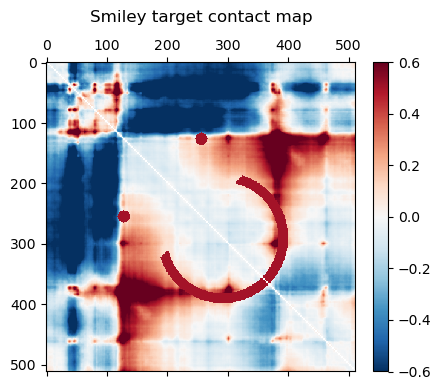

In [6]:
os.makedirs(TMP_DIR, exist_ok=True)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}\n")

print("Loading Akita v2 model …")
model = SeqNN()
model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
model.to(device).eval()
print("Model loaded.\n")

# One-hot sequence
genome  = Fasta(FASTA_PATH)
seq_str = genome[CHROM][START:END]
X_np    = one_hot_encode_sequence(seq_str)
X       = torch.tensor(X_np)
if X.dim() == 2:
    X = X.unsqueeze(0)
X = X.to(device)
SEQ_PATH = os.path.join(TMP_DIR, f"{STEM}_X.pt")
torch.save(X.cpu(), SEQ_PATH)
print(f"Sequence shape : {tuple(X.shape)}  → saved to {SEQ_PATH}")

# Cached tower activations
TOWER_PATH = os.path.join(TMP_DIR, f"{STEM}_tower_out.pt")
store_tower_output(X, model, TOWER_PATH)
tower = torch.load(TOWER_PATH, weights_only=True).to(device)
print(f"Tower shape    : {tuple(tower.shape)}  → saved to {TOWER_PATH}")

# Smiley target
target = make_target(model, X, smiley_indices.to(device), smiley_vector.to(device), device)
TARGET_PATH = os.path.join(TMP_DIR, f"{STEM}_smiley_target.pt")
torch.save(target, TARGET_PATH)
target = target.to(device)
print(f"Target shape   : {tuple(target.shape)}  → saved to {TARGET_PATH}")

# Preview
from utils.data_utils import from_upper_triu
mat_target = from_upper_triu(target[0, 0, :].cpu().numpy(), matrix_len=MAP_SIZE, num_diags=NUM_DIAGS)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.matshow(mat_target, cmap=CMAP, vmin=VMIN, vmax=VMAX)
ax.set_title("Smiley target contact map", pad=12)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## Cell 6 — Setting up Semifreddo and running the optimisation

In [7]:
sf_wrapper = SemifreddoLedidiWrapper(
    model                   = model,
    precomputed_full_output = tower,
    full_X                  = X,
    edited_bin              = CENTER_BIN_MAP,
    context_bins            = CONTEXT_BINS,
    cropping_applied        = CROPPING,
)

X_center = X[:, :, sf_wrapper.center_bp_start:sf_wrapper.center_bp_end]

local_output_loss = LocalL1Loss(
    smiley_indices.to(device), n_triu=N_TRIU, reduction="sum"
)
# LocalL1Loss stores the mask as a plain tensor attribute, so .to(device)
# does not move it. We move it explicitly here.
local_output_loss.mask = local_output_loss.mask.to(device)
local_output_loss = local_output_loss.to(device)

ledidi_optimizer = Ledidi(
    sf_wrapper,
    shape               = X_center.shape[1:],
    input_loss          = torch.nn.L1Loss(reduction="sum"),
    output_loss         = local_output_loss,
    batch_size          = 1,
    l                   = L,
    max_iter            = MAX_ITER,
    early_stopping_iter = EARLY_STOPPING,
    return_history      = True,
    verbose             = True,
).cuda()

print("Running optimisation … (this may take a few minutes)\n")
generated_seq, history = ledidi_optimizer.fit_transform(X_center, target)
print("\nOptimisation complete.")

Running optimisation … (this may take a few minutes)

iter=I	input_loss=0.0	output_loss=4.039e+04	total_loss=4.039e+04	time=0.0
iter=100	input_loss=21.0	output_loss=3.965e+04	total_loss=4.227e+04	time=7.391
iter=200	input_loss=13.0	output_loss=3.946e+04	total_loss=4.108e+04	time=7.304
iter=300	input_loss=25.0	output_loss=3.944e+04	total_loss=4.257e+04	time=7.306
iter=400	input_loss=20.0	output_loss=3.97e+04	total_loss=4.22e+04	time=7.304
iter=500	input_loss=30.0	output_loss=3.936e+04	total_loss=4.311e+04	time=7.307
iter=600	input_loss=11.0	output_loss=4.026e+04	total_loss=4.164e+04	time=7.313
iter=700	input_loss=25.0	output_loss=4.019e+04	total_loss=4.331e+04	time=7.313
iter=800	input_loss=45.0	output_loss=3.957e+04	total_loss=4.519e+04	time=7.312
iter=900	input_loss=20.0	output_loss=3.941e+04	total_loss=4.191e+04	time=7.313
iter=1000	input_loss=11.0	output_loss=4.019e+04	total_loss=4.157e+04	time=7.318
iter=1100	input_loss=33.0	output_loss=3.937e+04	total_loss=4.349e+04	time=7.317
ite

## Cell 7 — Visualising the result

We reconstruct the full sequence and run the full Akita model to get the
final predicted contact map, then display initial, target, and optimised
side by side.

Remember: smiley faces are completely out-of-distribution for Akita. Treat
the result with curiosity rather than as a validated design. If the optimised
map looks suspicious — uniform, collapsed, or heavily artefactual — it is a
sign that the optimiser could not reconcile the target with what the model
has learned. This is expected for arbitrary custom targets, and it is exactly
why all designs should be inspected visually before any biological
interpretation.

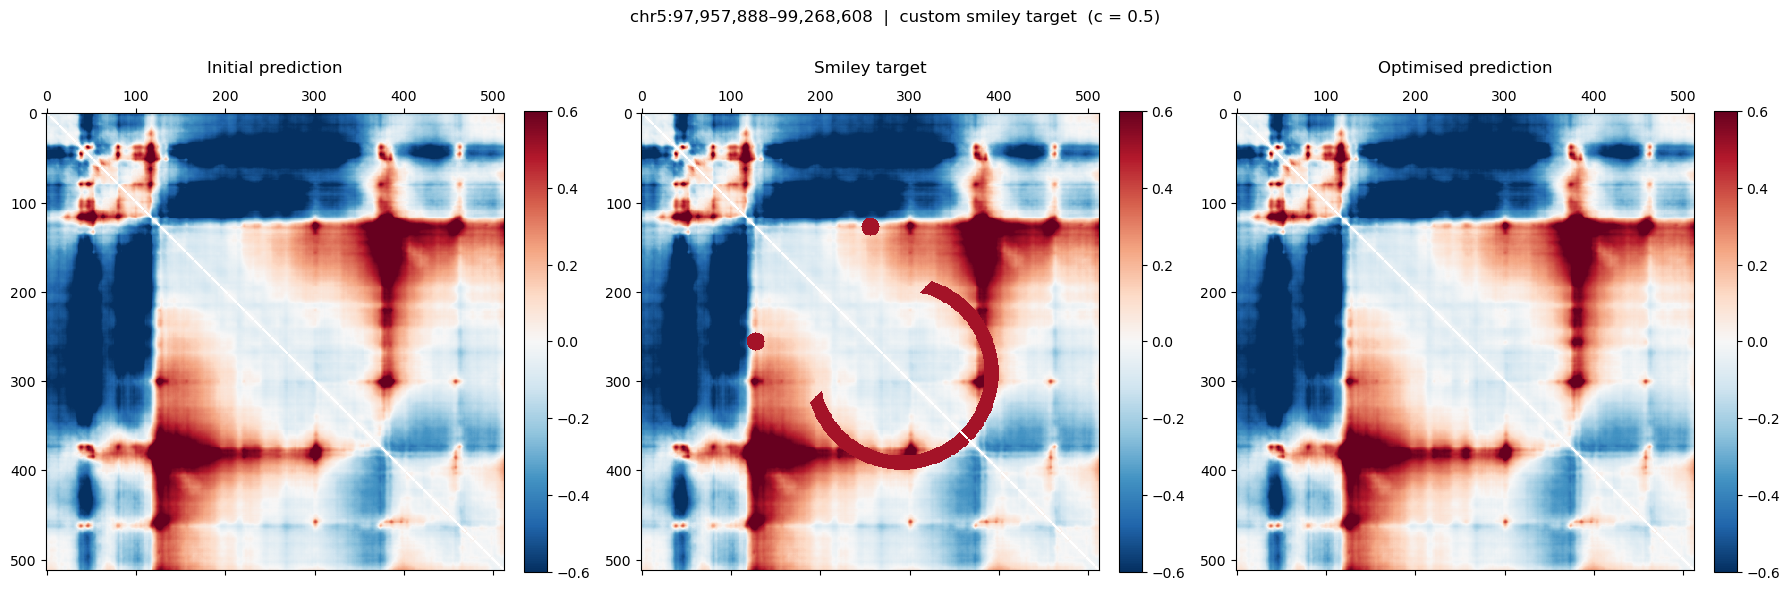

Edited nucleotides: 6 / 2,048 (0.3% of the central bin)

Does the optimised map look smiley-like? Probably not — and that is fine.
The point of this exercise is not to produce a valid biological design,
but to show that the only thing standing between you and any custom target
is the mask function in Cell 3.

Ideas for custom masks to try next:
  • A TAD stack (several nested square domains along the diagonal)
  • A stripe (elevated contacts across an entire row/column)
  • A dot at a specific off-diagonal position (loop between two loci)
  • Your own biological hypothesis expressed as a contact pattern


In [8]:
full_generated_seq = X.clone()
full_generated_seq[
    :, :, sf_wrapper.center_bp_start:sf_wrapper.center_bp_end
] = generated_seq

model.eval()
with torch.no_grad():
    pred_initial   = model(X)
    pred_optimised = model(full_generated_seq)

mat_initial   = from_upper_triu(pred_initial[0, 0, :].cpu().numpy(),   matrix_len=MAP_SIZE, num_diags=NUM_DIAGS)
mat_optimised = from_upper_triu(pred_optimised[0, 0, :].cpu().numpy(), matrix_len=MAP_SIZE, num_diags=NUM_DIAGS)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, mat, title in zip(
    axes,
    [mat_initial, mat_target, mat_optimised],
    ["Initial prediction", "Smiley target", "Optimised prediction"],
):
    im = ax.matshow(mat.astype(np.float32), cmap=CMAP, vmin=VMIN, vmax=VMAX)
    ax.set_title(title, pad=12)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(
    f"{CHROM}:{START:,}–{END:,}  |  custom smiley target  (c = {SMILEY_VALUE})",
    y=1.02,
)
plt.tight_layout()
plt.show()

n_edits = (
    torch.argmax(full_generated_seq, dim=1) != torch.argmax(X, dim=1)
).sum().item()
print(f"Edited nucleotides: {n_edits:,} / {BIN_SIZE:,} ({100 * n_edits / BIN_SIZE:.1f}% of the central bin)")
print()
print("Does the optimised map look smiley-like? Probably not — and that is fine.")
print("The point of this exercise is not to produce a valid biological design,")
print("but to show that the only thing standing between you and any custom target")
print("is the mask function in Cell 3.")
print()
print("Ideas for custom masks to try next:")
print("  • A TAD stack (several nested square domains along the diagonal)")
print("  • A stripe (elevated contacts across an entire row/column)")
print("  • A dot at a specific off-diagonal position (loop between two loci)")
print("  • Your own biological hypothesis expressed as a contact pattern")

## Cell 8 — Cleanup

In [10]:
shutil.rmtree(TMP_DIR)
print(f"Removed {TMP_DIR}/")
print()
print("─" * 70)
print("Tutorial 2 complete!")
print()
print("Key takeaway: a custom AkitaSF design target is just a mask function.")
print("Write create_my_target_mask(), plug it into LocalL1Loss, and the rest")
print("of the pipeline — Semifreddo, Ledidi, evaluation — is unchanged.")
print("─" * 70)

Removed tmp_data/

──────────────────────────────────────────────────────────────────────
Tutorial 2 complete!

Key takeaway: a custom AkitaSF design target is just a mask function.
Write create_my_target_mask(), plug it into LocalL1Loss, and the rest
of the pipeline — Semifreddo, Ledidi, evaluation — is unchanged.
──────────────────────────────────────────────────────────────────────
